In [5]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [6]:
dx.refresh_bokeh()

Loading BokehJS ...

In [7]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/motor_accuracy'
base_folder = '/home/jovyan/BACKUP/Pacome/motor_accuracy'

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


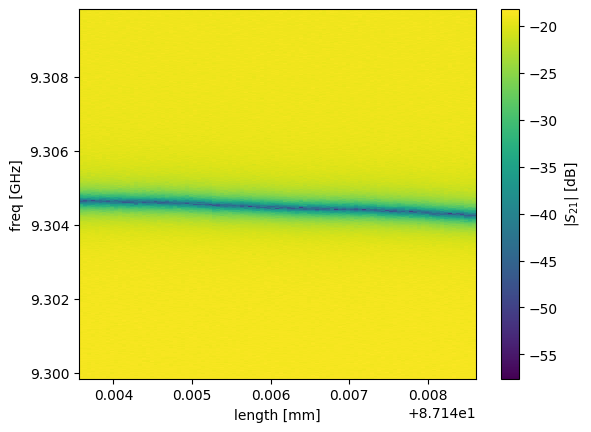

In [13]:
file_folder = '2026-06-23_14.56.34_0002_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_absolute = format_data_xarray(data, tool='VNA', translator=translator)
data_absolute.mag.plot()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


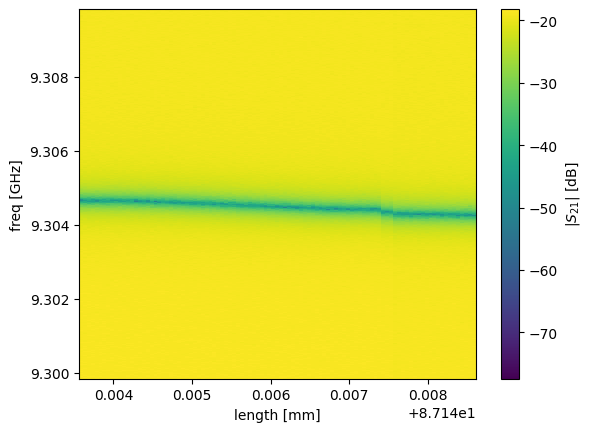

In [14]:
file_folder = '2026-06-23_15.29.03_0003_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_relative = format_data_xarray(data, tool='VNA', translator=translator)
data_relative.mag.plot()

## Absolute movement, step = 50nm

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


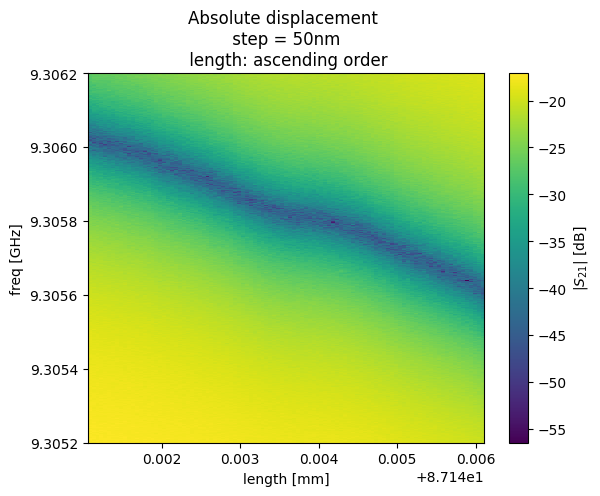

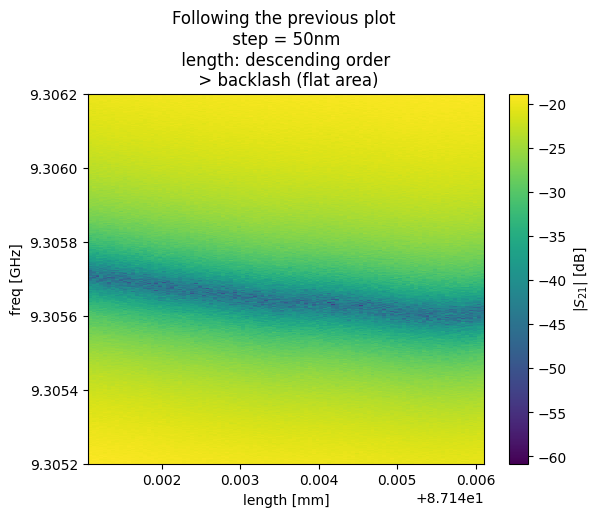

In [28]:
file_folder = '2026-06-24_10.31.14_0006_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_abs = format_data_xarray(data, tool='VNA', translator=translator)
length = data_abs.length.values
n = len(length)
_data = data_abs.isel(length = slice(0, n//2))
_data.mag.plot()
plt.title('Absolute displacement \n step = 50nm \n length: ascending order')
plt.show()

_data = data_abs.isel(length = slice(n//2, n))
_data.mag.plot()
plt.title('Following the previous plot \n step = 50nm \n length: descending order \n > backlash (flat area)')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
[87.145985 87.146035 87.146085 87.146085 87.146035 87.145985]


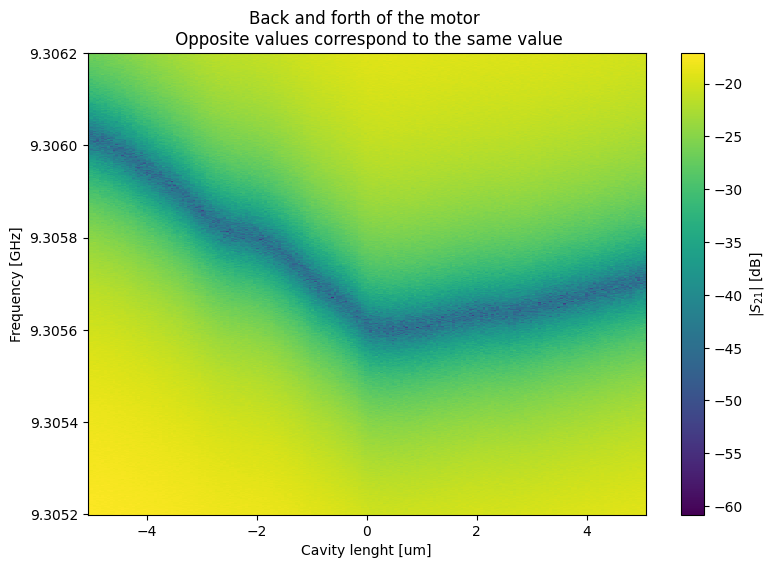

In [49]:
file_folder = '2026-06-24_10.31.14_0006_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_abs = format_data_xarray(data, tool='VNA', translator=translator)
length = data_abs.length.values
n = len(length)
data1 = data_abs.isel(length = slice(0, n//2))
data2 = data_abs.isel(length = slice(n//2, n))

freq = data1.freq.values
length_concat = np.concatenate((data1.length.values, data2.length.values))
new_length = np.linspace(-50*101, 50*101, 202)
mag_concat = np.concatenate((data1.mag.values, data2.mag.values), axis=1)
print(length_concat[n//2-3:n//2+3])

plt.figure(figsize=(9, 6))
plt.pcolormesh(new_length*1e-3, freq, mag_concat)
plt.xlabel('Cavity lenght [um]')
plt.ylabel('Frequency [GHz]')
plt.colorbar(label='$|S_{21}|$ [dB]')
plt.title('Back and forth of the motor \n Opposite values correspond to the same value')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


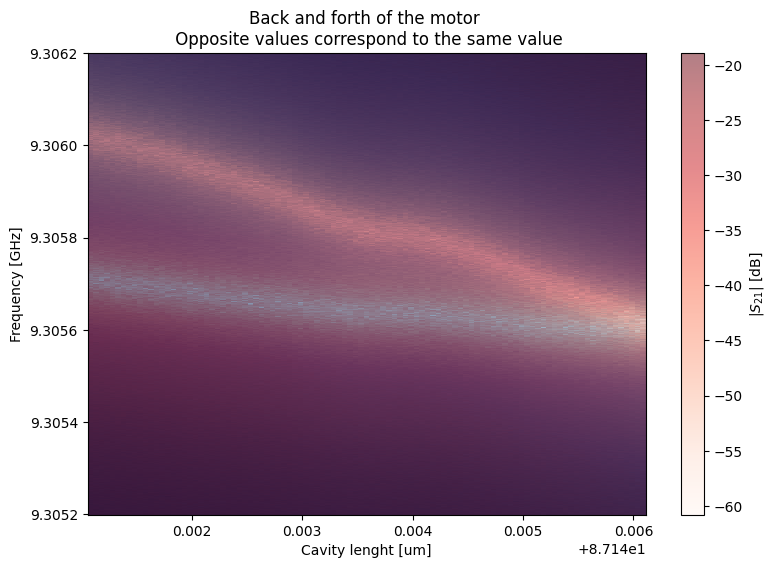

In [59]:
file_folder = '2026-06-24_10.31.14_0006_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_abs = format_data_xarray(data, tool='VNA', translator=translator)
length = data_abs.length.values
n = len(length)
data1 = data_abs.isel(length = slice(0, n//2))
data2 = data_abs.isel(length = slice(n//2, n))

plt.figure(figsize=(9, 6))
plt.pcolormesh(data1.length.values, data1.freq.values, data1.mag.values, alpha=1, cmap = 'Blues')
plt.pcolormesh(data2.length.values, data2.freq.values, data2.mag.values, alpha=0.5, cmap = 'Reds')
plt.xlabel('Cavity lenght [um]')
plt.ylabel('Frequency [GHz]')
plt.colorbar(label='$|S_{21}|$ [dB]')
plt.title('Back and forth of the motor \n Opposite values correspond to the same value')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


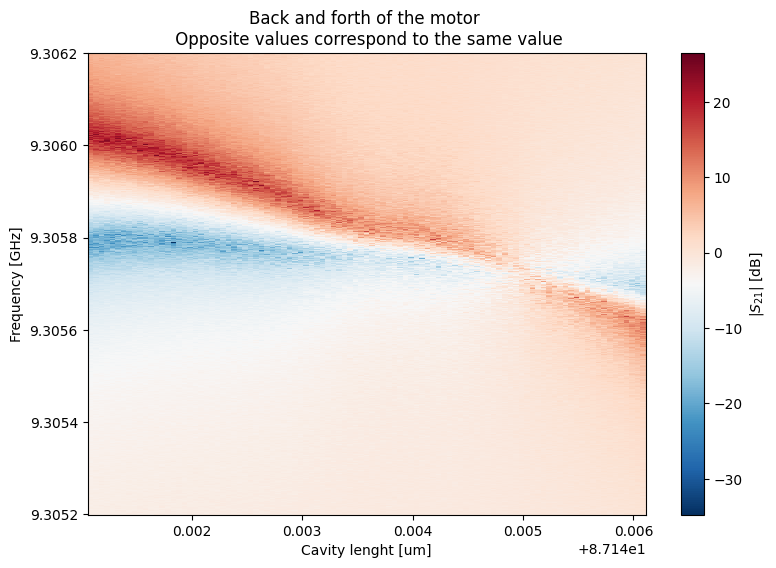

In [65]:
file_folder = '2026-06-24_10.31.14_0006_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_abs = format_data_xarray(data, tool='VNA', translator=translator)
length = data_abs.length.values
n = len(length)
data1 = data_abs.isel(length = slice(0, n//2))
data2 = data_abs.isel(length = slice(n//2, n))

plt.figure(figsize=(9, 6))
plt.pcolormesh(data1.length.values, data1.freq.values, data2.mag.values[::-1] - data1.mag.values, alpha=1, cmap = 'RdBu_r')
plt.xlabel('Cavity lenght [um]')
plt.ylabel('Frequency [GHz]')
plt.colorbar(label='$|S_{21}|$ [dB]')
plt.title('Back and forth of the motor \n Opposite values correspond to the same value')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


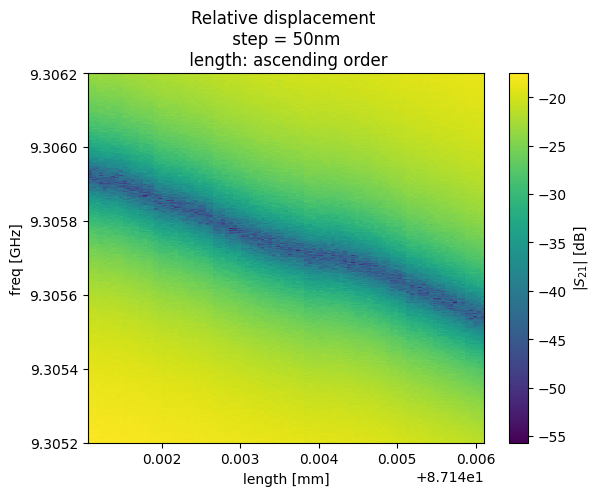

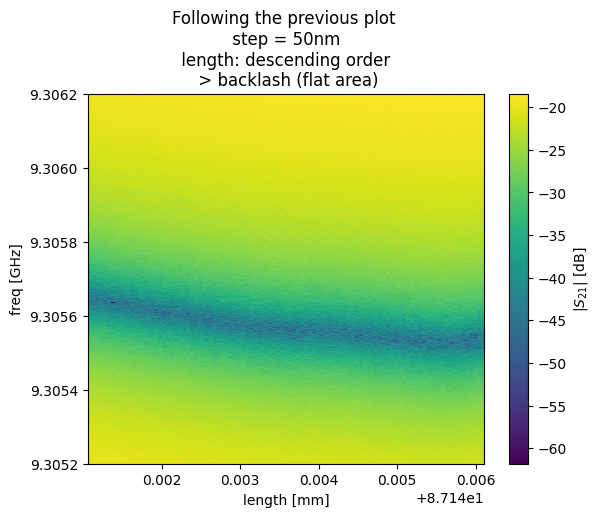

In [30]:
file_folder = '2026-06-24_10.23.02_0005_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_rel = format_data_xarray(data, tool='VNA', translator=translator)
length = data_rel.length.values
n = len(length)

_data = data_rel.isel(length = slice(0, n//2))
_data.mag.plot()
plt.title('Relative displacement \n step = 50nm \n length: ascending order')
plt.show()

_data = data_rel.isel(length = slice(n//2, n))
_data.mag.plot()
plt.title('Following the previous plot \n step = 50nm \n length: descending order \n > backlash (flat area)')
plt.show()